#### **1. Linear Regression, Outliers, and Regularization**

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

indexno = 220525   # index number, used as the fixed random seed

rng = np.random.default_rng(indexno)
X = rng.uniform(-3, 3, size=(160, 1))                   # 160 samples, one feature in [-3, 3]
y = 2.5 + 1.8 * X[:, 0] + rng.normal(0, 0.8, size=160)  # true line y = 2.5 + 1.8x plus N(0, 0.8) noise

# Add large errors to 12 observations.
outlier_idx = rng.choice(len(y), size=12, replace=False)  # rows chosen to be corrupted
y[outlier_idx] += rng.uniform(10, 15, size=12)            # shift them up by 10-15 (vertical outliers)

In [27]:
import os

os.makedirs('figures', exist_ok=True)

# Figure output quality settings
plt.rcParams['figure.dpi']     = 120    # on-screen preview
plt.rcParams['savefig.dpi']    = 500    # saved PNG files
plt.rcParams['savefig.bbox']   = 'tight'
plt.rcParams['font.size']      = 11
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.25
plt.rcParams['grid.linewidth'] = 0.6


def save_fig(name):
    """Save the current figure to figures/<name>.png at 500 dpi."""
    plt.savefig(f'figures/{name}.png', bbox_inches='tight')

**Question 1**  
Explain why Ordinary Least Squares (OLS) estimation is particularly sensitive to severe vertical outliers in y. Reference the squared loss function $J(\mathbf{w}) = \frac{1}{2N} \sum_{i} (y_i - \mathbf{w}^T\mathbf{x}_i)^2$ in your answer.

---

OLS gets w by minimizing $J(\mathbf{w}) = \frac{1}{2N} \sum_{i} (y_i - \mathbf{w}^T\mathbf{x}_i)^2$. The sensitivity to outliers direclty comes from squars of residuals. 
A residual of an inliner is very small like $\sigma$ = 0.7, so the $\sigma^2$ = 0.49.
But residual of an outlier is a more like 10 - 15 and the squared error is 100 - 255. Therefore vertical outlier contribute strongly to the $J(\mathbf{w})$. 
When trying to minimize, OLS pulls line towards the outliers moving line towards it while inlier residuals grow slightly causing disorting the true line.

---
**Question 2**

Fit an ordinary least-squares (OLS) model to the generated data. Report its fitted intercept ($w_0$), slope coefficient ($w_1$), training Mean Squared Error ($\text{MSE}_{\text{train}}$), and test Mean Squared Error ($\text{MSE}_{\text{test}}$). Provide a scatter plot showing the data points along with the fitted regression line.

---

Intercept (w0) = 3.3842
Slope     (w1) = 1.8197
MSE train      = 11.1480
MSE test       = 9.8696


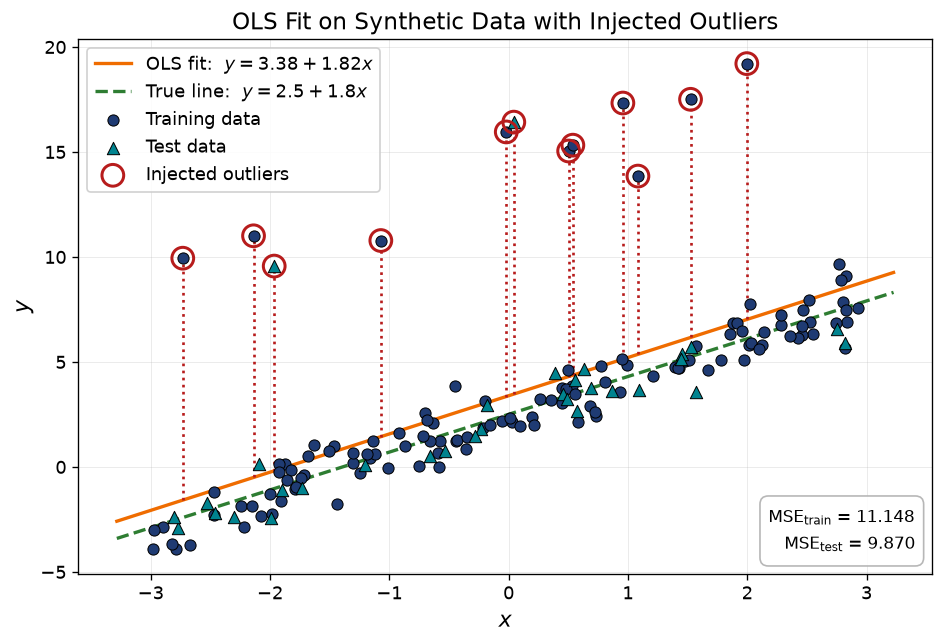

In [28]:
# 80:20 train/test split (as per the assignment instructions). The row indices
# are split alongside the data so Q3 can tell which rows are the outliers.
idx_all = np.arange(len(y))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, idx_all, test_size=0.20, random_state=42)

ols = LinearRegression()      # OLS on the training split
ols.fit(X_train, y_train)

w0 = ols.intercept_           # fitted intercept
w1 = ols.coef_[0]             # fitted slope
mse_train = mean_squared_error(y_train, ols.predict(X_train))
mse_test  = mean_squared_error(y_test,  ols.predict(X_test))

print(f"Intercept (w0) = {w0:.4f}")
print(f"Slope     (w1) = {w1:.4f}")
print(f"MSE train      = {mse_train:.4f}")
print(f"MSE test       = {mse_test:.4f}")

# Flatten to 1-D for plotting
Xf, X_tr, X_te = (np.asarray(a).ravel() for a in (X, X_train, X_test))
y_f, y_tr, y_te = (np.asarray(a).ravel() for a in (y, y_train, y_test))

x_line = np.linspace(Xf.min() - 0.3, Xf.max() + 0.3, 200)

fig, ax = plt.subplots(figsize=(8, 5.5))

# Candidate lines
ax.plot(x_line, w0 + w1 * x_line, color='#ef6c00', linewidth=2,
        label=rf'OLS fit:  $y = {w0:.2f} + {w1:.2f}x$')
ax.plot(x_line, 2.5 + 1.8 * x_line, color='#2e7d32', linewidth=2, linestyle='--',
        label=r'True line:  $y = 2.5 + 1.8x$')

# Data
ax.scatter(X_tr, y_tr, s=45, color='#1f3b73', zorder=3,
           edgecolor='black', linewidth=0.6, label='Training data')
ax.scatter(X_te, y_te, s=55, marker='^', color='#00838f', zorder=3,
           edgecolor='black', linewidth=0.6, label='Test data')
ax.scatter(Xf[outlier_idx], y_f[outlier_idx], s=170, facecolors='none',
           edgecolors='#b71c1c', linewidth=1.8, zorder=4,
           label='Injected outliers')

# Residual of each outlier against the OLS fit
for i in np.atleast_1d(outlier_idx):
    ax.vlines(Xf[i], w0 + w1 * Xf[i], y_f[i],
              color='#b71c1c', linestyle=':', linewidth=1.6, zorder=2)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('OLS Fit on Synthetic Data with Injected Outliers')
ax.annotate(rf'MSE$_\mathrm{{train}}$ = {mse_train:.3f}' '\n'
            rf'MSE$_\mathrm{{test}}$ = {mse_test:.3f}',
            xy=(0.98, 0.03), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=10, linespacing=1.6,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#b0b0b0', alpha=0.9))
ax.legend(framealpha=0.9, loc='upper left')

plt.tight_layout()
save_fig('ols_fit_outliers')
plt.show()

---
**Question 3**

Define $a_i \in (0, 1]$ as the sample-specific weight, where $a_i = 0.05$ for the known outliers and $a_i = 1.0$ for all inliers.

*Notation*
- $N$: Total number of training instances
- $D$: Number of feature dimensions
- $\boldsymbol{X} \in \mathbb{R}^{N \times (D+1)}$: Data/design matrix with an added lead column of ones for the intercept bias.
- $\boldsymbol{y} \in \mathbb{R}^{N}$: Target response vector $\boldsymbol{y} = [y_1, y_2, \ldots, y_N]^T$.
- $\boldsymbol{w} \in \mathbb{R}^{D+1}$: Parameter weight vector $\boldsymbol{w} = [w_0, w_1, \ldots w_{D+1}]^T$.
- $\boldsymbol{A} \in \mathbb{R}^{N \times N}$: Positive-definite diagonal weighting matrix $\boldsymbol{A} = \mathrm{diag}(a_1, a_2, \ldots, a_N)$.

Derive the closed-form matrix expression for the weighted least-squares estimator:

$$\hat{\boldsymbol{w}}_{\mathrm{WLS}} = (\boldsymbol{X}^T \boldsymbol{A} \boldsymbol{X})^{-1} \boldsymbol{X}^T \boldsymbol{A} \boldsymbol{y}.$$

Implement this WLS estimator using NumPy and compare its fitted line against standard OLS.

---


Weighted Least Squares

We have

$$
J(\mathbf{w}) =
\frac{1}{2N}
(\mathbf{y}-\mathbf{Xw})^T
\mathbf{A}
(\mathbf{y}-\mathbf{Xw})
$$

where $\mathbf{A}$ is a diagonal matrix containing the weights $\alpha_i$. The known outliers have weight $0.05$, while the inliers have weight $1.0$.

1. Expanding the objective

Expanding the quadratic expression,

$$
J(\mathbf{w}) =
\frac{1}{2N}
\left[
\mathbf{y}^T\mathbf{A}\mathbf{y}
-\mathbf{y}^T\mathbf{A}\mathbf{Xw}
-\mathbf{w}^T\mathbf{X}^T\mathbf{A}\mathbf{y}
+\mathbf{w}^T\mathbf{X}^T\mathbf{A}\mathbf{Xw}
\right].
$$

Since $\mathbf{A}$ is diagonal, it is symmetric. The two middle terms are scalars and are equal, so this becomes

$$
J(\mathbf{w}) =
\frac{1}{2N}
\left[
\mathbf{y}^T\mathbf{A}\mathbf{y}
-2\mathbf{w}^T\mathbf{X}^T\mathbf{A}\mathbf{y}
+\mathbf{w}^T\mathbf{X}^T\mathbf{A}\mathbf{Xw}
\right].
$$

2. Gradient

Taking the derivative with respect to $\mathbf{w}$,

$$
\nabla_{\mathbf{w}}J =
\frac{1}{2N}
\left[
-2\mathbf{X}^T\mathbf{A}\mathbf{y}
+2\mathbf{X}^T\mathbf{A}\mathbf{Xw}
\right].
$$

Therefore,

$$
\nabla_{\mathbf{w}}J =
\frac{1}{N}
\left(
\mathbf{X}^T\mathbf{A}\mathbf{Xw}
-\mathbf{X}^T\mathbf{A}\mathbf{y}
\right).
$$

3. Setting the gradient to zero

For the minimum, we set the gradient equal to zero:

$$
\mathbf{X}^T\mathbf{A}\mathbf{X}\hat{\mathbf{w}}
=

\mathbf{X}^T\mathbf{A}\mathbf{y}.
$$

These are the weighted normal equations.

4. Solving for $\hat{\mathbf{w}}$

All the weights $\alpha_i$ are positive, so $\mathbf{A}$ is positive definite. Assuming that $\mathbf{X}$ has full column rank, $\mathbf{X}^T\mathbf{A}\mathbf{X}$ is invertible.

Thus,

$$
\hat{\mathbf{w}}_{\mathrm{WLS}}
=

(\mathbf{X}^T\mathbf{A}\mathbf{X})^{-1}
\mathbf{X}^T\mathbf{A}\mathbf{y}.
$$

5. Checking the minimum

The Hessian is

$$
\nabla_{\mathbf{w}}^2 J
=

\frac{1}{N}
\mathbf{X}^T\mathbf{A}\mathbf{X}.
$$

Since $\mathbf{X}^T\mathbf{A}\mathbf{X}$ is positive definite, the Hessian is also positive definite. Therefore, the stationary point is the unique global minimum of $J(\mathbf{w})$.

Hence, the weighted least-squares solution is

$$
\hat{\mathbf{w}}_{\mathrm{WLS}}
=

(\mathbf{X}^T\mathbf{A}\mathbf{X})^{-1}
\mathbf{X}^T\mathbf{A}\mathbf{y}.
$$


In [29]:
# ---------------------------------------------------------------
# NumPy implementation of the OLS and WLS closed-form estimators
# ---------------------------------------------------------------

# Boolean outlier mask over the full dataset, then mapped onto each split
is_out = np.zeros(len(y), dtype=bool)
is_out[outlier_idx] = True

out_train = is_out[idx_train]   # which training rows are outliers
out_test  = is_out[idx_test]    # which test rows are outliers

print(f"Outliers in training set: {out_train.sum()} / {len(out_train)}")
print(f"Outliers in test set    : {out_test.sum()} / {len(out_test)}")


def design_matrix(x):
    """Return X with the lead column of ones for the intercept bias."""
    x = np.asarray(x).reshape(len(x), -1)
    return np.column_stack([np.ones(len(x)), x])


Xd_train = design_matrix(X_train)
Xd_test  = design_matrix(X_test)

# Sample-specific weights: a_i = 0.05 for known outliers, a_i = 1.0 for inliers
a = np.where(out_train, 0.05, 1.0)
A = np.diag(a)                  # diagonal weighting matrix

# OLS :  w = (X^T X)^-1 X^T y        (the special case A = I)
# WLS :  w = (X^T A X)^-1 X^T A y
# np.linalg.solve is the numerically stable way to evaluate these closed forms
w_ols = np.linalg.solve(Xd_train.T @ Xd_train, Xd_train.T @ y_train)
w_wls = np.linalg.solve(Xd_train.T @ A @ Xd_train, Xd_train.T @ A @ y_train)

# Check the closed-form OLS reproduces the sklearn fit from Q2
assert np.allclose(w_ols, [w0, w1]), "Closed-form OLS disagrees with sklearn"


def mse(Xd, y_true, w, mask=None):
    """Mean squared error, optionally over a subset of rows."""
    resid = y_true - Xd @ w
    if mask is not None:
        resid = resid[mask]
    return float(np.mean(resid ** 2))


# Overall test MSE is dominated by the outliers WLS deliberately ignores, so the
# inlier-only MSE is reported too - that is what shows the benefit of weighting
print(f"\n{'Model':<6}{'w0':>9}{'w1':>9}{'MSE_train':>12}{'MSE_test':>11}"
      f"{'MSE_test (inliers)':>21}")
for name, w in (("OLS", w_ols), ("WLS", w_wls)):
    print(f"{name:<6}{w[0]:>9.4f}{w[1]:>9.4f}"
          f"{mse(Xd_train, y_train, w):>12.4f}"
          f"{mse(Xd_test, y_test, w):>11.4f}"
          f"{mse(Xd_test, y_test, w, ~out_test):>21.4f}")
print(f"{'True':<6}{2.5:>9.4f}{1.8:>9.4f}")

print("\nEuclidean distance from the true parameters [2.5, 1.8]:")
print(f"  ||w_ols - w_true|| = {np.linalg.norm(w_ols - [2.5, 1.8]):.4f}")
print(f"  ||w_wls - w_true|| = {np.linalg.norm(w_wls - [2.5, 1.8]):.4f}")

Outliers in training set: 10 / 128
Outliers in test set    : 2 / 32

Model        w0       w1   MSE_train   MSE_test   MSE_test (inliers)
OLS      3.3842   1.8197     11.1480     9.8696               1.7663
WLS      2.4926   1.8394     11.9395    10.1487               0.6348
True     2.5000   1.8000

Euclidean distance from the true parameters [2.5, 1.8]:
  ||w_ols - w_true|| = 0.8844
  ||w_wls - w_true|| = 0.0401


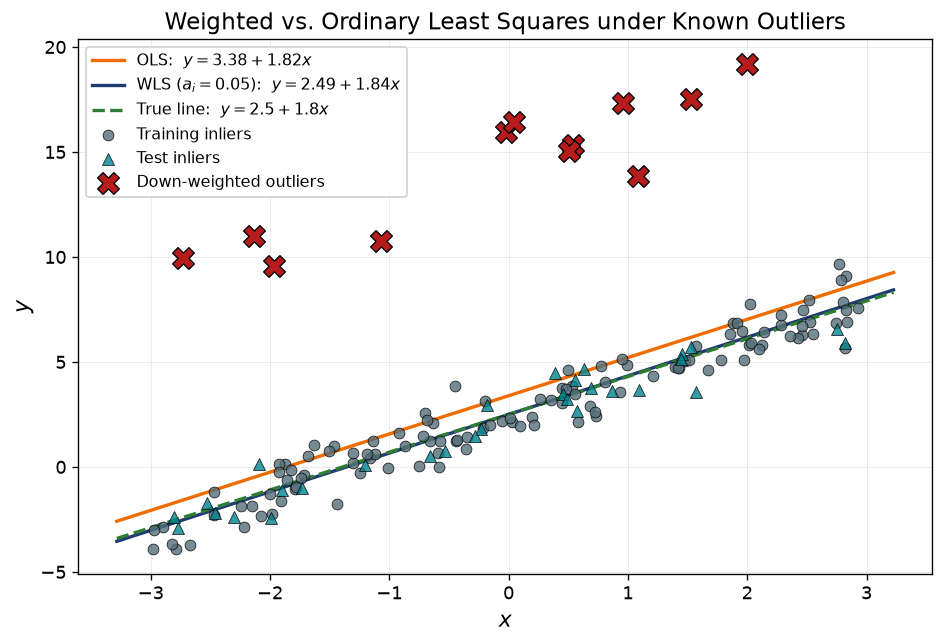

In [30]:
# ---------------------------------------------------------------
# WLS vs OLS fitted lines
# ---------------------------------------------------------------
Xf   = np.asarray(X).ravel()
X_tr = np.asarray(X_train).ravel()
X_te = np.asarray(X_test).ravel()

x_line = np.linspace(Xf.min() - 0.3, Xf.max() + 0.3, 200)

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(x_line, w_ols[0] + w_ols[1] * x_line, color='#ef6c00', linewidth=2,
        label=rf'OLS:  $y = {w_ols[0]:.2f} + {w_ols[1]:.2f}x$')
ax.plot(x_line, w_wls[0] + w_wls[1] * x_line, color='#1f3b73', linewidth=2,
        label=rf'WLS ($a_i = 0.05$):  $y = {w_wls[0]:.2f} + {w_wls[1]:.2f}x$')
ax.plot(x_line, 2.5 + 1.8 * x_line, color='#2e7d32', linewidth=2, linestyle='--',
        label=r'True line:  $y = 2.5 + 1.8x$')

ax.scatter(X_tr[~out_train], y_train[~out_train], s=42, color='#546e7a',
           zorder=3, edgecolor='black', linewidth=0.5, alpha=0.8,
           label='Training inliers')
ax.scatter(X_te[~out_test], y_test[~out_test], s=52, marker='^',
           color='#00838f', zorder=3, edgecolor='black', linewidth=0.5,
           alpha=0.8, label='Test inliers')
ax.scatter(Xf[is_out], y[is_out], s=170, marker='X', color='#b71c1c',
           zorder=4, edgecolor='black', linewidth=0.8,
           label=r'Down-weighted outliers')

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Weighted vs. Ordinary Least Squares under Known Outliers')
ax.legend(framealpha=0.9, loc='upper left', fontsize=9.5)

plt.tight_layout()
save_fig('q3_wls_vs_ols')
plt.show()

---
**Question 4**

**Regularization in High Dimensions:**

Create an expanded dataset containing nine pure noise variables:

```python
X_noise = rng.normal(size=(X.shape[0], 9))
X10 = np.column_stack([X, X_noise])
```

Fit OLS, Ridge Regression ($L_2$), and Lasso Regression ($L_1$). Tune the regularization strength hyperparameter $\alpha \in \{10^{-3}, 10^{-2}, 10^{-1}, 1, 10\}$ using 5-fold cross-validation. Report optimal $\alpha^*$ values and cross-validated test MSEs.

---


In [ ]:
# OLS / Ridge / Lasso on 1 informative + 9 pure-noise features

from sklearn.model_selection import GridSearchCV

# Nine pure noise variables appended to the single real feature. This draws from
# the same rng stream as Listing 1, so the cells must be run in order.
X_noise = rng.normal(size=(X.shape[0], 9))
X10 = np.column_stack([X, X_noise])      # 160 x 10: column 0 real, columns 1-9 noise

# Same 80:20 split and seed as Q2, so the two questions stay comparable
X10_train, X10_test, y10_train, y10_test = train_test_split(
    X10, y, test_size=0.20, random_state=42)
assert np.array_equal(y10_train, y_train)   # confirms it is the same partition

alphas = [1e-3, 1e-2, 1e-1, 1.0, 10.0]      # regularization strengths to search

# Each estimator sits behind a StandardScaler in a Pipeline, so the scaler is
# refitted inside every CV fold - fitting it once on the whole training set
# would leak validation-fold statistics into training. OLS has no alpha to tune.
models = {
    'OLS':   (LinearRegression(),    {}),
    'Ridge': (Ridge(),               {'reg__alpha': alphas}),
    'Lasso': (Lasso(max_iter=50000), {'reg__alpha': alphas}),
}

rows, coefs = [], {}
for name, (est, grid) in models.items():
    pipe = Pipeline([('scale', StandardScaler()), ('reg', est)])
    search = GridSearchCV(pipe, grid, cv=5, scoring='neg_mean_squared_error')
    search.fit(X10_train, y10_train)

    best_alpha = search.best_params_.get('reg__alpha')       # None for OLS
    cv_mse   = -search.best_score_                           # mean 5-fold CV MSE
    test_mse = mean_squared_error(y10_test, search.predict(X10_test))

    # Clip numerically tiny values to exactly zero so Lasso's dropped features
    # are unambiguous
    w = search.best_estimator_.named_steps['reg'].coef_
    w = np.where(np.abs(w) < 1e-8, 0.0, w)
    coefs[name] = w
    n_zero = int(np.sum(w[1:] == 0.0))       # noise coefficients driven to zero
    rows.append((name, best_alpha, cv_mse, test_mse, n_zero))

print(f"{'Model':<8}{'alpha*':>9}{'CV MSE':>11}{'Test MSE':>11}{'noise coefs = 0':>18}")
for name, alpha, cv_mse, test_mse, n_zero in rows:
    alpha_str = '-' if alpha is None else f'{alpha:g}'
    print(f"{name:<8}{alpha_str:>9}{cv_mse:>11.4f}{test_mse:>11.4f}"
          f"{f'{n_zero} / 9':>18}")

# Coefficients on the standardized features, so magnitudes are comparable
print("\nFitted coefficients (feature 0 is the real one, 1-9 are pure noise):")
print(f"{'':<8}" + ''.join(f'{i:>8}' for i in range(10)))
for name in models:
    print(f"{name:<8}" + ''.join(f'{c:>8.3f}' for c in coefs[name]))

Model      alpha*     CV MSE   Test MSE   noise coefs = 0
OLS             -    14.0434    10.3007             0 / 9
Ridge          10    13.7966    10.0921             0 / 9
Lasso           1    12.3842    10.1284             9 / 9

Fitted coefficients (feature 0 is the real one, 1-9 are pure noise):
               0       1       2       3       4       5       6       7       8       9
OLS        3.165  -0.026   0.070  -0.078  -0.157  -0.486   0.150  -0.329   0.062  -0.332
Ridge      2.922  -0.008   0.057  -0.055  -0.128  -0.419   0.138  -0.295   0.078  -0.331
Lasso      2.111   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000


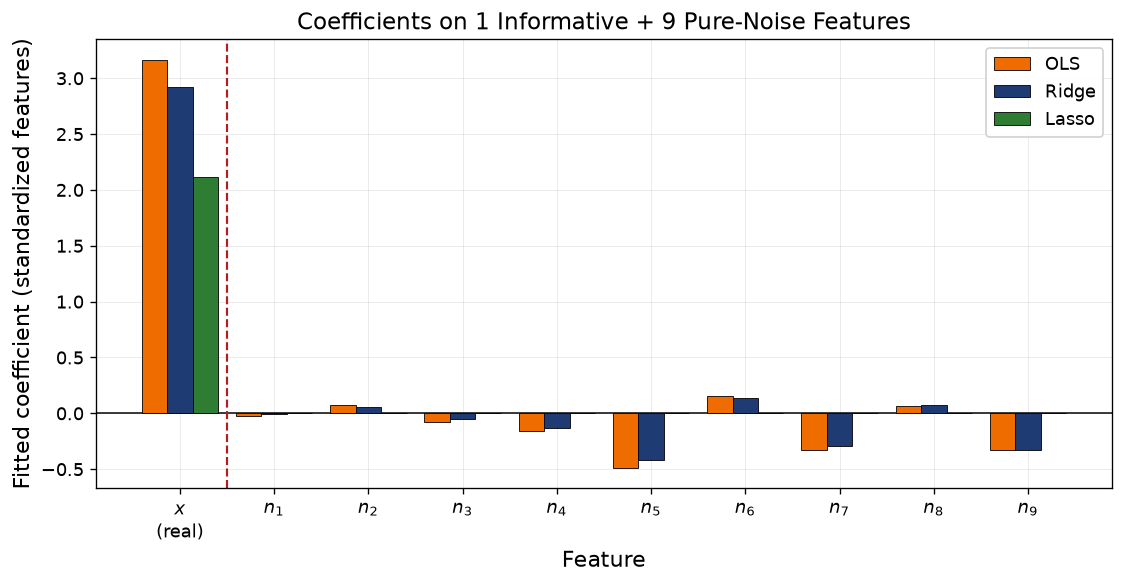

In [ ]:
# Coefficient magnitudes: real feature vs. the nine noise features

fig, ax = plt.subplots(figsize=(9.5, 5))

idx = np.arange(10)
width = 0.27

for i, (name, color) in enumerate(zip(('OLS', 'Ridge', 'Lasso'),
                                      ('#ef6c00', '#1f3b73', '#2e7d32'))):
    ax.bar(idx + (i - 1) * width, coefs[name], width, label=name,
           color=color, edgecolor='black', linewidth=0.5, zorder=3)

ax.axhline(0, color='black', linewidth=0.9, zorder=2)
ax.axvline(0.5, color='#b71c1c', linestyle='--', linewidth=1.3, zorder=2)

ax.set_xticks(idx)
ax.set_xticklabels(['$x$\n(real)'] + [f'$n_{i}$' for i in range(1, 10)])
ax.set_xlabel('Feature')
ax.set_ylabel('Fitted coefficient (standardized features)')
ax.set_title('Coefficients on 1 Informative + 9 Pure-Noise Features')
ax.legend(framealpha=0.9, loc='upper right')

plt.tight_layout()
save_fig('q4_coefficients')
plt.show()